In [60]:
####Import the needed package
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import gc
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint

###########################################################################################################################1
#####Here we have defined functions to get the equilibrium monomer and droplet-mass concentration as a result of LLPS
# Function definitions
def func(x, coef, nd, phi0):
    return coef * (x ** nd) * (nd + x - nd * x) - (1 - x) * (1 - x) * (phi0 - x)

def f1p(x, coef, nd, phi0):
    return coef * (x ** (nd - 1)) * (nd * (nd + x - nd * x) + x * (1 - nd)) + (1 - x) * (2 * (phi0 - x) + (1 - x))

def f2p(x, coef, nd, phi0):
    return coef * (x ** (nd - 2)) * (nd * (nd - 1) * (nd + x - nd * x) + 2 * nd * (1 - nd) * x) - 2 * (phi0 - 3 * x + 2)

def solve_equilibrium(phi_bn, phi_sn, nd, initial_concentration):
    phi0 = initial_concentration / phi_bn
    coef = (phi_bn / phi_sn) ** (nd - 1)

    # Newton-Raphson method
    sigma = phi0 if phi0 <= 1 else 1
    tol = 1.0e-8
    for i in range(10):
        fx = func(sigma, coef, nd, phi0)
        f1px = f1p(sigma, coef, nd, phi0)
        f2px = f2p(sigma, coef, nd, phi0)

        r = 1 - fx * f2px / (2 * f1px ** 2)
        r = max(min(r, 1.2), 0.8)  # Clamp r between 0.8 and 1.2

        delta = -fx / (f1px * r)
        sigma += delta

        if abs(delta) < tol:
            break

    equilibrium_monomer = sigma * phi_bn
    droplet = (phi0 - sigma) * phi_bn
    #Apply threshold: if droplet < 10^-10, set it to 0
    droplet = droplet if droplet >= 1e-10 else 0.0
    print(f"Equilibrium monomer: {equilibrium_monomer:.16f}, Droplet: {droplet:.16f}")

    return equilibrium_monomer, droplet


In [61]:
### These are the model parameters 
global switch
p0= [
    15,        # 0  droplet-intermediates dissociation rate
    10,        # 1  droplet-monomer dissociation rate
    30,        # 2  droplet binodal point
    15,        # 3  droplet nucleation size
    4,         # 4  oligomer1 nucleation size
    0,         # 5  not used
    0,         # 6  not used
    0.01,      # 7  fibril1 critical concentration 
    1e-5,      # 8  monomer-oligomer1 dissociation rate in droplet
    1e-8,      # 9  monomer-fibril1 dissociation rate in droplet
    1e-5,      #10  monomer-oligomer1 dissociation rate in solution
    1e-8,      #11  monomer-fibril1 dissociation rate in solution
    0,         #12  not used
    6,         #13  oligomer1→fibril1 conformational change barrier in droplet
    6,         #14  oligomer1→fibril1 conformational change barrierbarrier in solution
    1,         #15  alpha-coefficient
    0,         #16  not used
    0,         #17  not used
    0,         #18  not used
    0,         #19  not used
    1e-5,      #20  monomer-oligomer2 dissociation in droplet
    1e-8,      #21  monomer-fibril2 dissociation in droplet
    1e-5,      #22  monomer-oligomer2 dissociation in solution
    1e-8,      #23  monomer-fibril2 dissociation in solution
    6,         #24  oligomer2 nucleation size
    6,         #25  oligomer2→fibril2 conformational change barrier in droplet
    6,         #26  oligomer2→fibril2 conformational change barrier in solution
    0,         #27  not used
    0,         #28  not used
    0,         #29  not used
    0.01       #30  fibril2 critical concentration
]


In [62]:
##### Function for rate-mass equations for low concentration regime
def func0(t, u, p, Kdn_norm1, MDm1, y0, K):
    global switch, MDm
    du = [0] * 61
################################
    Kdp=K[0]   # monomer-droplet association rate
    Kdn= K[1]  # droplet nucleation rate

    Kf2p= K[2] # monomer-fibril association rate in the solution
    Kfn2= K[3] # oligomer nucleation rate in the solution

    Kf2p2= K[4] # monomer-fibril association rate in the solution
    Kfn22= K[5] # oligomer nucleation rate in the solution

####### Initial droplet nucleation and growth terms###############################################################################
    AAA= (u[0]/y0)**p[3]   ###### droplet nucleation normalized by K_dn*p[2]**Nd, denoted as Kdn_norm1
    AA=  p[3]*AAA
    BB=  (p[1]/p[2]*u[0] - p[1])*u[1]
    BBB= (p[1]/p[2]*u[0] + p[0])*u[2]
    CC=  p[0]*p[3]*u[2]- p[1]*u[2]
    CCC= p[0]* u[2]
    CCCC=p[1]* u[10]

  ### If kinetics maximum droplet mass is greater than equilibrium droplet mass, update the maximum droplet mass value
    MDm11 = MDm1
    if (u[3]*Kdn_norm1 > MDm):
        MDm = u[3]*Kdn_norm1
    if (MDm > MDm11):
        MDm11 = MDm
######################################################################################################################################
  # Define the approximation for higher order fibril in droplets  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[7]:
            nf1plus1= u[36]

        else:
            nf1plus1= u[36]*(p[2]/p[7])
    else:
        nf1plus1= 0
  # Define the approximation for higher order fibril in solution  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[7]:
            nf2plus1= u[27]
        else:
            nf2plus1= u[27]*(u[0]/p[7])
    else:
        nf2plus1= 0


  # Define the approximation for higher order fibril2 in droplets  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[30]:
            nf1plus12= u[60]

        else:
            nf1plus12= u[60]*(p[2]/p[30])
    else:
        nf1plus12= 0
  # Define the approximation for higher order fibril2 in solution  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[30]:
            nf2plus12= u[51]
        else:
            nf2plus12= u[51]*(u[0]/p[30])
    else:
        nf2plus12= 0

  ####################################################################################################################################22
  ## fibrilization terms in droplet phase
    
    # fibrilization1 terms in droplet phase
    DDDmd= p[15]*Kfn2*u[3]*p[2]**(p[4]-1)                                                                    # normalized oligomer number (primary + secondary) nucleation in the droplets
    DDmd=  p[4]*DDDmd;                                                                                       # normalized oligomer mass nucleation in the droplets
    MM1md= p[15]*p[4]*p[8]*u[4]*u[3]/MDm11                                                                   # normalized oligomer disintegration into droplet-monomer
    FFmd= (p[15]*Kf2p*p[2]-p[15]*p[9])*u[5]*u[3]/MDm11 + p[15]*p[9]* u[28]* u[3]/MDm11                       # normalized growth and shrinking of the fibril in the droplets
    MMM1md= (p[15]*Kf2p*p[2]*u[4] - p[15]*p[9]*u[28])*np.exp(-p[13])*u[3]/MDm11                              # normalized fibril nucleation from oligomer


    DDD= p[15]*Kfn2*Kdn_norm1*u[3]*p[2]**(p[4]-1)                                                            # normalized oligomer number (primary + secondary) nucleation in the droplets
    FF= (p[15]*Kf2p*p[2]-p[15]*p[9])*u[5]*u[3]*Kdn_norm1/MDm11 + p[15]*p[9]* u[28]* u[3]*Kdn_norm1/MDm11     # Unnormalized growth and shrinking of the fibril in the droplets
    FF1= (Kf2p*u[0]-p[11])*u[5]*(1-u[3]*Kdn_norm1/MDm11) + p[11]*u[28]*(1-u[3]*Kdn_norm1/MDm11)              # Unnormalized fibril (nucleated within droplets) growth by solution monomer
    MMM1=  (p[15]*Kf2p*p[2]*u[4] - p[15]*p[9]*u[28])*np.exp(-p[13])*u[3]*Kdn_norm1/MDm11                     # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by droplet monomer
    MMM2=  (Kf2p*u[0]*u[4] - p[11]*u[28])*np.exp(-p[14])*(1-u[3]*Kdn_norm1/MDm11)                            # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by solution monomer
    MMM= MMM1 + MMM2
    MM= (p[4]+1)*MMM
    MM11= p[15]*p[4]*p[8]*u[4]*(1-u[3]*Kdn_norm1/MDm1)                                                       # Unnormalized oligomer disintegration into solution-monomer
    MM2= p[15]*p[8]*u[4]                                                                                     # Oligomer disintegration


    # fibrilization2 terms in droplet phase
  
    DDDmd2= p[15]*Kfn22*u[3]*p[2]**(p[24]-1)                                                                  # normalized oligomer number (primary + secondary) nucleation in the droplets
    DDmd2=  p[24]*DDDmd2;                                                                                     # normalized oligomer mass nucleation in the droplets
    MM1md2= p[15]*p[24]*p[20]*u[37]*u[3]/MDm11                                                                # normalized oligomer disintegration into droplet-monomer
    FFmd2= (p[15]*Kf2p2*p[2]-p[15]*p[21])*u[38]*u[3]/MDm11 + p[15]*p[21]* u[52]* u[3]/MDm11                   # normalized growth and shrinking of the fibril in the droplets
    MMM1md2= (p[15]*Kf2p2*p[2]*u[37] - p[15]*p[21]*u[52])*np.exp(-p[25])*u[3]/MDm11                           # normalized fibril nucleation from oligomer

  
    DDD2= p[15]*Kfn22*Kdn_norm1*u[3]*p[2]**(p[24]-1)                                                          # normalized oligomer number (primary + secondary) nucleation in the droplets
    FF2= (p[15]*Kf2p2*p[2]-p[15]*p[21])*u[38]*u[3]*Kdn_norm1/MDm11 + p[15]*p[21]* u[52]* u[3]*Kdn_norm1/MDm11 # Unnormalized growth and shrinking of the fibril in the droplets
    FF12= (Kf2p2*u[0]-p[23])*u[38]*(1-u[3]*Kdn_norm1/MDm11) + p[23]*u[52]*(1-u[3]*Kdn_norm1/MDm11)            # Unnormalized fibril (nucleated within droplets) growth by solution monomer
    MMM12=  (p[15]*Kf2p2*p[2]*u[37] - p[15]*p[21]*u[52])*np.exp(-p[25])*u[3]*Kdn_norm1/MDm11                  # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by droplet monomer
    MMM22=  (Kf2p2*u[0]*u[37] - p[23]*u[52])*np.exp(-p[26])*(1-u[3]*Kdn_norm1/MDm11)                          # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by solution monomer
    MMM_2= MMM12 + MMM22
    MM_2= (p[24]+1)*MMM_2
    MM112= p[15]*p[24]*p[20]*u[37]*(1-u[3]*Kdn_norm1/MDm1)                                                    # Unnormalized oligomer disintegration into solution-monomer
    MM22= p[15]*p[20]*u[37]

  ######################################################################################################################################23
  ##fibrilization terms in solution phase
    
    ### fibrilization1 terms in solution phase
    EEE = Kfn2*u[0]**p[4]                                                                                    # Oligomer number (primary + secondary) nucleation in the solution
    EE  = p[4]*EEE;                                                                                          # Monomer loss due to oligomer nucleation in the solution
    GG  = (Kf2p*u[0]-p[11])*u[8] + p[11]*u[19];                                                              # Growth and shrinking of the fibril in the solution
    NNN = p[10]*u[7]                                                                                         # Oligomer number disintegration to monomer
    NN  = p[4]*NNN                                                                                           # Oligomer-mass disintegration
    NN1 = (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])                                                      # Fibril nucleation from oligomer
    NN2 = (p[4]+1)* NN1                                                                                      # Fibril mass nucleation from oligomer
  
    ### fibrilization2 terms in solution phase
    EEE2 = Kfn22*u[0]**p[24]                                                                                 # Oligomer number (primary + secondary) nucleation in the solution
    EE2  = p[24]*EEE2;                                                                                       # Monomer loss due to oligomer nucleation in the solution
    GG2  = (Kf2p2*u[0]-p[23])*u[41] + p[23]*u[43];                                                           # Growth and shrinking of the fibril in the solution
    NNN2 = p[22]*u[40]                                                                                       # Oligomer number disintegration to monomer
    NN_2 = p[24]*NNN2                                                                                        # Oligomer-mass disintegration
    NN12 = (Kf2p2*u[0]*u[40] - p[23]*u[43])*np.exp(-p[26])                                                   # Fibril nucleation from oligomer
    NN22 = (p[24]+1)* NN12                                                                                   # Fibril mass nucleation from oligomer
  ########################################################################################################################################24
  ## Restoring the monomer-droplet equilibrium due to monomer loss within droplets due to fibrilization within droplets
    if Kdn_norm1*u[3]>0:
        MM3= (DDmd - MM1md + FFmd + MMM1md)/u[3]*u[1]
        MM4= (DDmd - MM1md + FFmd + MMM1md)/u[3]*u[2]
    else:
        MM3=0
        MM4=0


    if Kdn_norm1*u[3]>0:
        MM32= (DDmd2 - MM1md2+ FFmd2 + MMM1md2)/u[3]*u[1]
        MM42= (DDmd2 - MM1md2 + FFmd2 + MMM1md2)/u[3]*u[2]
    else:
        MM32=0
        MM42=0

  #########################################################################################################################################25
  ## Restoring the monomer-droplet equilibrium due to monomer loss due to fibrilization in solution phase
    sigma= u[0]/p[2]
    kdeno= p[3] + sigma - sigma*p[3]
    knum= 1 + kdeno
    con= 0.1
    if u[0] >= p[2] or (u[1]>0 and u[2]/u[1]>= (1-sigma)*(1+con)):
        KK= 0
        KKK= 0
    else:
        KK= (FF1 + MMM2 - MM11 + EE -NN +GG +NN1 )/u[0]*u[1]* sigma/(1-sigma)* 1/kdeno
        KKK= (FF1 + MMM2 - MM11 + EE -NN +GG +NN1 )/u[0]*u[2]*sigma/(1-sigma)* knum/kdeno

    if u[0] >= p[2] or (u[1]>0 and u[2]/u[1]>= (1-sigma)*(1+con)):
        KK2= 0
        KKK2= 0
    else:
        KK2= (FF12 + MMM22 - MM112 + EE2 -NN_2 +GG2 +NN12 )/u[0]*u[1]* sigma/(1-sigma)* 1/kdeno
        KKK2= (FF12 + MMM22 - MM112 + EE2 -NN_2 +GG2 +NN12 )/u[0]*u[2]*sigma/(1-sigma)* knum/kdeno
  ###########################################################################################################################################26
  # Set the approximation for the higher droplet size to truncate the hierarchical dependency
    if u[0]>= p[2]:
        nd2plus1= u[18]
    else:
        nd2plus1= u[18]* sigma
  
  ############################################################################################################################################27
  #print(u[0]+u[3]+u[4]+u[6]+u[7]+u[9]+u[37]+u[39]+u[40]+u[42])
  #print(u[0],u[3],u[4],u[6],u[7],u[9],[37],u[39],u[40],u[42])
  #Rate-mass equations
  ##u[0]= monomer concenctration
  ##u[1]= droplet number, Cd
  ##u[2]= smallest droplet number, nd
  ##u[3]= droplet mass D
  ##u[4]= oligomer mass in droplet
  ##u[5]= Fibril number concentration in dropt
  ##u[6]= fibril mass in droplet
  ##u[7]= oligomer mass in solution
  ##u[8]= fibril number concentration in solution
  ##u[9]= fibril mass in solution
    du[0] = -(AA + BB - CC)* Kdn_norm1 - (FF1 + MMM2 - MM11) - EE + NN - GG - NN1 -(FF12 + MMM22 - MM112) - EE2 + NN_2 - GG2 - NN12
    du[1] =  AAA - CCC - KK - MM3- KK2- MM32
    du[2]=  AAA - BBB + CCCC - KKK - MM4 -KKK2 - MM42
    du[3] = (AA + BB - CC) - (DDmd - MM1md +FFmd + MMM1md)  - (DDmd2 - MM1md2 +FFmd2 + MMM1md2)

    du[4]= DDD  - MM2 - MMM
    du[5] = MMM 
    du[6] = (MM + FF + FF1)
    du[7]= EEE - NNN - NN1
    du[8] = NN1 
    du[9] = NN2 + GG

  ##u[37]= oligomer mass in droplet
  ##u[38]= Fibril number concentration in dropt
  ##u[39]= fibril mass in droplet
  ##u[40]= oligomer mass in solution
  ##u[41]= fibril number concentration in solution
  ##u[42]= fibril mass in solution
    du[37]= DDD2  - MM22 - MMM_2 #<- u[10]
    du[38] = MMM_2  #<-u[11]
    du[39] = (MM_2 + FF2 + FF12) #<-u[12]
    du[40]= (EEE2 - NNN2 - NN12) #<-u[13]
    du[41] = NN12 #<-u[14]
    du[42] = NN22 + GG2#<-u[15]
  ##########################################################################################################################################28
  # Higher order droplets rate-mass equations and truncate high-oreder dependency
    du[10]= (p[1]/p[2]*u[0])*u[2] -(p[1]/p[2]*u[0] + p[1])*u[10] + p[1]*u[11]
    du[11]= (p[1]/p[2]*u[0])*u[10] -(p[1]/p[2]*u[0] + p[1])*u[11] + p[1]*u[12]
    du[12]= (p[1]/p[2]*u[0])*u[11] -(p[1]/p[2]*u[0] + p[1])*u[12] + p[1]*u[13]
    du[13]= (p[1]/p[2]*u[0])*u[12] -(p[1]/p[2]*u[0] + p[1])*u[13] + p[1]*u[14]
    du[14]= (p[1]/p[2]*u[0])*u[13] -(p[1]/p[2]*u[0] + p[1])*u[14] + p[1]*u[15]
    du[15]= (p[1]/p[2]*u[0])*u[14] -(p[1]/p[2]*u[0] + p[1])*u[15] + p[1]*u[16]
    du[16]= (p[1]/p[2]*u[0])*u[15] -(p[1]/p[2]*u[0] + p[1])*u[16] + p[1]*u[17]
    du[17]= (p[1]/p[2]*u[0])*u[16] -(p[1]/p[2]*u[0] + p[1])*u[17] + p[1]*u[18]
    du[18]= (p[1]/p[2]*u[0])*u[17] -(p[1]/p[2]*u[0] + p[1])*u[18] + p[1]*nd2plus1
  ###########################################################################################################################################29
  # # Higher order fibrils (in solution)rate-mass equations and truncate high-oreder dependency
    du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
    du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
    du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
    du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
    du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
    du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
    du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
    du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
    du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
  ###########################################################################################################################################30
  # Higher order fibrils (in droplets) rate-mass equation and truncate high-oreder dependency
    du[28]=(p[15]*Kf2p*p[2]*u[4]*np.exp(-p[14])-(p[15]*Kf2p*p[2]+ p[15]*p[11]*np.exp(-p[14]))*u[28] + p[15]*p[11]*u[29])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[4]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[28] + p[11]*u[29])*(1-Kdn_norm1*u[3]/MDm11)
    du[29]=(p[15]*Kf2p*p[2]*u[28]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[29] + p[15]*p[11]*u[30])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[28] -(Kf2p*u[0] + p[11])*u[29] + p[11]*u[30])*(1-Kdn_norm1*u[3]/MDm11)
    du[30]=(p[15]*Kf2p*p[2]*u[29]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[30] + p[15]*p[11]*u[31])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[29] -(Kf2p*u[0] + p[11])*u[30] + p[11]*u[31])*(1-Kdn_norm1*u[3]/MDm11)
    du[31]=(p[15]*Kf2p*p[2]*u[30]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[31] + p[15]*p[11]*u[32])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[30] -(Kf2p*u[0] + p[11])*u[31] + p[11]*u[32])*(1-Kdn_norm1*u[3]/MDm11)
    du[32]=(p[15]*Kf2p*p[2]*u[31]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[32] + p[15]*p[11]*u[33])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[31] -(Kf2p*u[0] + p[11])*u[32] + p[11]*u[33])*(1-Kdn_norm1*u[3]/MDm11)
    du[33]=(p[15]*Kf2p*p[2]*u[32]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[33] + p[15]*p[11]*u[34])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[32] -(Kf2p*u[0] + p[11])*u[33] + p[11]*u[34])*(1-Kdn_norm1*u[3]/MDm11)
    du[34]=(p[15]*Kf2p*p[2]*u[33]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[34] + p[15]*p[11]*u[35])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[33] -(Kf2p*u[0] + p[11])*u[34] + p[11]*u[35])*(1-Kdn_norm1*u[3]/MDm11)
    du[35]=(p[15]*Kf2p*p[2]*u[34]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[35] + p[15]*p[11]*u[36])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[34] -(Kf2p*u[0] + p[11])*u[35] + p[11]*u[36])*(1-Kdn_norm1*u[3]/MDm11)
    du[36]=(p[15]*Kf2p*p[2]*u[35]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[36] + p[15]*p[11]*nf1plus1)*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[35] -(Kf2p*u[0] + p[11])*u[36] + p[11]*nf1plus1)*(1-Kdn_norm1*u[3]/MDm11)
  ###########################################################################################################################################################################################################31
  # Higher order fibrils2 (in solution) rate-mass equations and truncate high-order dependency
    du[43] = Kf2p2*u[0]*u[40]*np.exp(-p[26]) -(Kf2p2*u[0] + p[23]*np.exp(-p[26]))*u[43] + p[23]*u[44]
    du[44] = Kf2p2*u[0]*u[43] -(Kf2p2*u[0] + p[23])*u[44] + p[23]*u[45]
    du[45] = Kf2p2*u[0]*u[44] -(Kf2p2*u[0] + p[23])*u[45] + p[23]*u[46]
    du[46] = Kf2p2*u[0]*u[45] -(Kf2p2*u[0] + p[23])*u[46] + p[23]*u[47]
    du[47] = Kf2p2*u[0]*u[46] -(Kf2p2*u[0] + p[23])*u[47] + p[23]*u[48]
    du[48] = Kf2p2*u[0]*u[47] -(Kf2p2*u[0] + p[23])*u[48] + p[23]*u[49]
    du[49] = Kf2p2*u[0]*u[48] -(Kf2p2*u[0] + p[23])*u[49] + p[23]*u[50]
    du[50] = Kf2p2*u[0]*u[49] -(Kf2p2*u[0] + p[23])*u[50] + p[23]*u[51]
    du[51] = Kf2p2*u[0]*u[50] -(Kf2p2*u[0] + p[23])*u[51] + p[23]*nf2plus12
  ###########################################################################################################################################30
  # Higher order fibrils2 (in droplets) rate-mass equation and truncate high-order dependency
    du[52]=  (p[15]*Kf2p2*p[2]*u[37]*np.exp(-p[26])-(p[15]*Kf2p2*p[2]+ p[15]*p[23]*np.exp(-p[26]))*u[52] + p[15]*p[23]*u[53])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[37]*np.exp(-p[26]) -(Kf2p2*u[0] + p[23]*np.exp(-p[26]))*u[52] + p[23]*u[53])*(1-Kdn_norm1*u[3]/MDm11)
    du[53] = (p[15]*Kf2p2*p[2]*u[52]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[53] + p[15]*p[23]*u[54])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[52] -(Kf2p2*u[0] + p[23])*u[53] + p[23]*u[54])*(1-Kdn_norm1*u[3]/MDm11)
    du[54] = (p[15]*Kf2p2*p[2]*u[53]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[54] + p[15]*p[23]*u[55])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[53] -(Kf2p2*u[0] + p[23])*u[54] + p[23]*u[55])*(1-Kdn_norm1*u[3]/MDm11)
    du[55] = (p[15]*Kf2p2*p[2]*u[54]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[55] + p[15]*p[23]*u[56])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[54] -(Kf2p2*u[0] + p[23])*u[55] + p[23]*u[56])*(1-Kdn_norm1*u[3]/MDm11)
    du[56] = (p[15]*Kf2p2*p[2]*u[55]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[56] + p[15]*p[23]*u[57])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[55] -(Kf2p2*u[0] + p[23])*u[56] + p[23]*u[57])*(1-Kdn_norm1*u[3]/MDm11)
    du[57] = (p[15]*Kf2p2*p[2]*u[56]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[57] + p[15]*p[23]*u[58])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[56] -(Kf2p2*u[0] + p[23])*u[57] + p[23]*u[58])*(1-Kdn_norm1*u[3]/MDm11)
    du[58] = (p[15]*Kf2p2*p[2]*u[57]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[58] + p[15]*p[23]*u[59])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[57] -(Kf2p2*u[0] + p[23])*u[58] + p[23]*u[59])*(1-Kdn_norm1*u[3]/MDm11)
    du[59] = (p[15]*Kf2p2*p[2]*u[58]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[59] + p[15]*p[23]*u[60])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[58] -(Kf2p2*u[0] + p[23])*u[59] + p[23]*u[60])*(1-Kdn_norm1*u[3]/MDm11)
    du[60]= (p[15]*Kf2p2*p[2]*u[59]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[60] + p[15]*p[23]*nf1plus12)*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[59] -(Kf2p2*u[0] + p[23])*u[60] + p[23]*nf1plus12)*(1-Kdn_norm1*u[3]/MDm11)
  # ##########F2
  # We set up here that the change in droplet-number concentration is in accordance with the change in droplet-mass concentration.
    if switch == 0 and (Kdn_norm1*u[3]/MDm11 >= 0.999 or du[3]<= 0) and (u[0]+ Kdn_norm1*u[3]<= y0):
        switch = 1;
    if switch == 1 :
        if u[3] >0:
            Kdf= du[3]/u[3]
            du[2]=Kdf*u[2] - (knum/kdeno)*u[2]*du[0]/u[0]*sigma/(1-sigma)
            du[1]=Kdf*u[1] - (1/kdeno)*u[1]*du[0]/u[0]*sigma/(1-sigma)
        else:
            du[1]=0
            du[2]=0
  ############################################################################################################################################32
    if y0< p[2] or y0>1000:
        conservedMass= u[0]+Kdn_norm1*u[3]+u[4]+u[6]+u[7]+u[9]+u[37]+u[39]+u[40]+u[42]
        for i in range(0, 19):
            if u[i] <0 and du[i]<0:
                du[i]= 0


        for i in range(37, 43):
            if u[i] <0 and du[i]<0:
                du[i]= 0

        for i in [4, 6, 7, 9, 37, 39, 40, 42]:
            if conservedMass> y0 and du[i]>0:
                du[i]=0

  #print(f"du={du}")
    return du

In [63]:
##### Function for rate-mass equations for low concentration regime
def func1(t, u, p, Kdn_norm1, MDm1, y0, K):
    global switch, MDm
    du = [0] * 61
################################
    Kdp=K[0]   # monomer-droplet association rate
    Kdn= K[1]  # droplet nucleation rate

    Kf2p= K[2] # monomer-fibril association rate in the solution
    Kfn2= K[3] # oligomer nucleation rate in the solution

    Kf2p2= K[4] # monomer-fibril association rate in the solution
    Kfn22= K[5] # oligomer nucleation rate in the solution

####### Initial droplet nucleation and growth terms###############################################################################
    AAA= (u[0]/p[2])**p[3]   ###### droplet nucleation normalized by K_dn*p[2]**Nd, denoted as Kdn_norm1
    AA=  p[3]*AAA
    BB=  (p[1]/p[2]*u[0] - p[1])*u[1]
    BBB= (p[1]/p[2]*u[0] + p[0])*u[2]
    CC=  p[0]*p[3]*u[2]- p[1]*u[2]
    CCC= p[0]* u[2]
    CCCC=p[1]* u[10]

  ### If kinetics maximum droplet mass is greater than equilibrium droplet mass, update the maximum droplet mass value
    MDm11 = MDm1
    if (u[3]*Kdn_norm1 > MDm):
        MDm = u[3]*Kdn_norm1
    if (MDm > MDm11):
        MDm11 = MDm
######################################################################################################################################
  # Define the approximation for higher order fibril in droplets  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[7]:
            nf1plus1= u[36]

        else:
            nf1plus1= u[36]*(p[2]/p[7])
    else:
        nf1plus1= 0
  # Define the approximation for higher order fibril in solution  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[7]:
            nf2plus1= u[27]
        else:
            nf2plus1= u[27]*(u[0]/p[7])
    else:
        nf2plus1= 0


  # Define the approximation for higher order fibril2 in droplets  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[30]:
            nf1plus12= u[60]

        else:
            nf1plus12= u[60]*(p[2]/p[30])
    else:
        nf1plus12= 0
  # Define the approximation for higher order fibril2 in solution  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[30]:
            nf2plus12= u[51]
        else:
            nf2plus12= u[51]*(u[0]/p[30])
    else:
        nf2plus12= 0

  ####################################################################################################################################22
  ## fibrilization terms in droplet phase
    
    # fibrilization1 terms in droplet phase
    DDDmd= p[15]*Kfn2*u[3]*p[2]**(p[4]-1)                                                                    # normalized oligomer number (primary + secondary) nucleation in the droplets
    DDmd=  p[4]*DDDmd;                                                                                       # normalized oligomer mass nucleation in the droplets
    MM1md= p[15]*p[4]*p[8]*u[4]*u[3]/MDm11                                                                   # normalized oligomer disintegration into droplet-monomer
    FFmd= (p[15]*Kf2p*p[2]-p[15]*p[9])*u[5]*u[3]/MDm11 + p[15]*p[9]* u[28]* u[3]/MDm11                       # normalized growth and shrinking of the fibril in the droplets
    MMM1md= (p[15]*Kf2p*p[2]*u[4] - p[15]*p[9]*u[28])*np.exp(-p[13])*u[3]/MDm11                              # normalized fibril nucleation from oligomer


    DDD= p[15]*Kfn2*Kdn_norm1*u[3]*p[2]**(p[4]-1)                                                            # normalized oligomer number (primary + secondary) nucleation in the droplets
    FF= (p[15]*Kf2p*p[2]-p[15]*p[9])*u[5]*u[3]*Kdn_norm1/MDm11 + p[15]*p[9]* u[28]* u[3]*Kdn_norm1/MDm11     # Unnormalized growth and shrinking of the fibril in the droplets
    FF1= (Kf2p*u[0]-p[11])*u[5]*(1-u[3]*Kdn_norm1/MDm11) + p[11]*u[28]*(1-u[3]*Kdn_norm1/MDm11)              # Unnormalized fibril (nucleated within droplets) growth by solution monomer
    MMM1=  (p[15]*Kf2p*p[2]*u[4] - p[15]*p[9]*u[28])*np.exp(-p[13])*u[3]*Kdn_norm1/MDm11                     # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by droplet monomer
    MMM2=  (Kf2p*u[0]*u[4] - p[11]*u[28])*np.exp(-p[14])*(1-u[3]*Kdn_norm1/MDm11)                            # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by solution monomer
    MMM= MMM1 + MMM2
    MM= (p[4]+1)*MMM
    MM11= p[15]*p[4]*p[8]*u[4]*(1-u[3]*Kdn_norm1/MDm1)                                                       # Unnormalized oligomer disintegration into solution-monomer
    MM2= p[15]*p[8]*u[4]                                                                                     # Oligomer disintegration


    # fibrilization2 terms in droplet phase
  
    DDDmd2= p[15]*Kfn22*u[3]*p[2]**(p[24]-1)                                                                  # normalized oligomer number (primary + secondary) nucleation in the droplets
    DDmd2=  p[24]*DDDmd2;                                                                                     # normalized oligomer mass nucleation in the droplets
    MM1md2= p[15]*p[24]*p[20]*u[37]*u[3]/MDm11                                                                # normalized oligomer disintegration into droplet-monomer
    FFmd2= (p[15]*Kf2p2*p[2]-p[15]*p[21])*u[38]*u[3]/MDm11 + p[15]*p[21]* u[52]* u[3]/MDm11                   # normalized growth and shrinking of the fibril in the droplets
    MMM1md2= (p[15]*Kf2p2*p[2]*u[37] - p[15]*p[21]*u[52])*np.exp(-p[25])*u[3]/MDm11                           # normalized fibril nucleation from oligomer

  
    DDD2= p[15]*Kfn22*Kdn_norm1*u[3]*p[2]**(p[24]-1)                                                          # normalized oligomer number (primary + secondary) nucleation in the droplets
    FF2= (p[15]*Kf2p2*p[2]-p[15]*p[21])*u[38]*u[3]*Kdn_norm1/MDm11 + p[15]*p[21]* u[52]* u[3]*Kdn_norm1/MDm11 # Unnormalized growth and shrinking of the fibril in the droplets
    FF12= (Kf2p2*u[0]-p[23])*u[38]*(1-u[3]*Kdn_norm1/MDm11) + p[23]*u[52]*(1-u[3]*Kdn_norm1/MDm11)            # Unnormalized fibril (nucleated within droplets) growth by solution monomer
    MMM12=  (p[15]*Kf2p2*p[2]*u[37] - p[15]*p[21]*u[52])*np.exp(-p[25])*u[3]*Kdn_norm1/MDm11                  # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by droplet monomer
    MMM22=  (Kf2p2*u[0]*u[37] - p[23]*u[52])*np.exp(-p[26])*(1-u[3]*Kdn_norm1/MDm11)                          # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by solution monomer
    MMM_2= MMM12 + MMM22
    MM_2= (p[24]+1)*MMM_2
    MM112= p[15]*p[24]*p[20]*u[37]*(1-u[3]*Kdn_norm1/MDm1)                                                    # Unnormalized oligomer disintegration into solution-monomer
    MM22= p[15]*p[20]*u[37]

  ######################################################################################################################################23
  ##fibrilization terms in solution phase
    
    ### fibrilization1 terms in solution phase
    EEE = Kfn2*u[0]**p[4]                                                                                    # Oligomer number (primary + secondary) nucleation in the solution
    EE  = p[4]*EEE;                                                                                          # Monomer loss due to oligomer nucleation in the solution
    GG  = (Kf2p*u[0]-p[11])*u[8] + p[11]*u[19];                                                              # Growth and shrinking of the fibril in the solution
    NNN = p[10]*u[7]                                                                                         # Oligomer number disintegration to monomer
    NN  = p[4]*NNN                                                                                           # Oligomer-mass disintegration
    NN1 = (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])                                                      # Fibril nucleation from oligomer
    NN2 = (p[4]+1)* NN1                                                                                      # Fibril mass nucleation from oligomer
  
    ### fibrilization2 terms in solution phase
    EEE2 = Kfn22*u[0]**p[24]                                                                                 # Oligomer number (primary + secondary) nucleation in the solution
    EE2  = p[24]*EEE2;                                                                                       # Monomer loss due to oligomer nucleation in the solution
    GG2  = (Kf2p2*u[0]-p[23])*u[41] + p[23]*u[43];                                                           # Growth and shrinking of the fibril in the solution
    NNN2 = p[22]*u[40]                                                                                       # Oligomer number disintegration to monomer
    NN_2 = p[24]*NNN2                                                                                        # Oligomer-mass disintegration
    NN12 = (Kf2p2*u[0]*u[40] - p[23]*u[43])*np.exp(-p[26])                                                   # Fibril nucleation from oligomer
    NN22 = (p[24]+1)* NN12                                                                                   # Fibril mass nucleation from oligomer
  ########################################################################################################################################24
  ## Restoring the monomer-droplet equilibrium due to monomer loss within droplets due to fibrilization within droplets
    if Kdn_norm1*u[3]>0:
        MM3= (DDmd - MM1md + FFmd + MMM1md)/u[3]*u[1]
        MM4= (DDmd - MM1md + FFmd + MMM1md)/u[3]*u[2]
    else:
        MM3=0
        MM4=0


    if Kdn_norm1*u[3]>0:
        MM32= (DDmd2 - MM1md2+ FFmd2 + MMM1md2)/u[3]*u[1]
        MM42= (DDmd2 - MM1md2 + FFmd2 + MMM1md2)/u[3]*u[2]
    else:
        MM32=0
        MM42=0

  #########################################################################################################################################25
  ## Restoring the monomer-droplet equilibrium due to monomer loss due to fibrilization in solution phase
    sigma= u[0]/p[2]
    kdeno= p[3] + sigma - sigma*p[3]
    knum= 1 + kdeno
    con= 0.1
    if u[0] >= p[2] or (u[1]>0 and u[2]/u[1]>= (1-sigma)*(1+con)):
        KK= 0
        KKK= 0
    else:
        KK= (FF1 + MMM2 - MM11 + EE -NN +GG +NN1 )/u[0]*u[1]* sigma/(1-sigma)* 1/kdeno
        KKK= (FF1 + MMM2 - MM11 + EE -NN +GG +NN1 )/u[0]*u[2]*sigma/(1-sigma)* knum/kdeno

    if u[0] >= p[2] or (u[1]>0 and u[2]/u[1]>= (1-sigma)*(1+con)):
        KK2= 0
        KKK2= 0
    else:
        KK2= (FF12 + MMM22 - MM112 + EE2 -NN_2 +GG2 +NN12 )/u[0]*u[1]* sigma/(1-sigma)* 1/kdeno
        KKK2= (FF12 + MMM22 - MM112 + EE2 -NN_2 +GG2 +NN12 )/u[0]*u[2]*sigma/(1-sigma)* knum/kdeno
  ###########################################################################################################################################26
  # Set the approximation for the higher droplet size to truncate the hierarchical dependency
    if u[0]>= p[2]:
        nd2plus1= u[18]
    else:
        nd2plus1= u[18]* sigma
  
  ############################################################################################################################################27
  #print(u[0]+u[3]+u[4]+u[6]+u[7]+u[9]+u[37]+u[39]+u[40]+u[42])
  #print(u[0],u[3],u[4],u[6],u[7],u[9],[37],u[39],u[40],u[42])
  #Rate-mass equations
  ##u[0]= monomer concenctration
  ##u[1]= droplet number, Cd
  ##u[2]= smallest droplet number, nd
  ##u[3]= droplet mass D
  ##u[4]= oligomer mass in droplet
  ##u[5]= Fibril number concentration in dropt
  ##u[6]= fibril mass in droplet
  ##u[7]= oligomer mass in solution
  ##u[8]= fibril number concentration in solution
  ##u[9]= fibril mass in solution
    du[0] = -(AA + BB - CC)* Kdn_norm1 - (FF1 + MMM2 - MM11) - EE + NN - GG - NN1 -(FF12 + MMM22 - MM112) - EE2 + NN_2 - GG2 - NN12
    du[1] =  AAA - CCC - KK - MM3- KK2- MM32
    du[2]=  AAA - BBB + CCCC - KKK - MM4 -KKK2 - MM42
    du[3] = (AA + BB - CC) - (DDmd - MM1md +FFmd + MMM1md)  - (DDmd2 - MM1md2 +FFmd2 + MMM1md2)

    du[4]= DDD  - MM2 - MMM
    du[5] = MMM 
    du[6] = (MM + FF + FF1)
    du[7]= EEE - NNN - NN1
    du[8] = NN1 
    du[9] = NN2 + GG

  ##u[37]= oligomer mass in droplet
  ##u[38]= Fibril number concentration in dropt
  ##u[39]= fibril mass in droplet
  ##u[40]= oligomer mass in solution
  ##u[41]= fibril number concentration in solution
  ##u[42]= fibril mass in solution
    du[37]= DDD2  - MM22 - MMM_2 #<- u[10]
    du[38] = MMM_2  #<-u[11]
    du[39] = (MM_2 + FF2 + FF12) #<-u[12]
    du[40]= (EEE2 - NNN2 - NN12) #<-u[13]
    du[41] = NN12 #<-u[14]
    du[42] = NN22 + GG2#<-u[15]
  ##########################################################################################################################################28
  # Higher order droplets rate-mass equations and truncate high-oreder dependency
    du[10]= (p[1]/p[2]*u[0])*u[2] -(p[1]/p[2]*u[0] + p[1])*u[10] + p[1]*u[11]
    du[11]= (p[1]/p[2]*u[0])*u[10] -(p[1]/p[2]*u[0] + p[1])*u[11] + p[1]*u[12]
    du[12]= (p[1]/p[2]*u[0])*u[11] -(p[1]/p[2]*u[0] + p[1])*u[12] + p[1]*u[13]
    du[13]= (p[1]/p[2]*u[0])*u[12] -(p[1]/p[2]*u[0] + p[1])*u[13] + p[1]*u[14]
    du[14]= (p[1]/p[2]*u[0])*u[13] -(p[1]/p[2]*u[0] + p[1])*u[14] + p[1]*u[15]
    du[15]= (p[1]/p[2]*u[0])*u[14] -(p[1]/p[2]*u[0] + p[1])*u[15] + p[1]*u[16]
    du[16]= (p[1]/p[2]*u[0])*u[15] -(p[1]/p[2]*u[0] + p[1])*u[16] + p[1]*u[17]
    du[17]= (p[1]/p[2]*u[0])*u[16] -(p[1]/p[2]*u[0] + p[1])*u[17] + p[1]*u[18]
    du[18]= (p[1]/p[2]*u[0])*u[17] -(p[1]/p[2]*u[0] + p[1])*u[18] + p[1]*nd2plus1
  ###########################################################################################################################################29
  # # Higher order fibrils (in solution)rate-mass equations and truncate high-oreder dependency
    du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
    du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
    du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
    du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
    du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
    du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
    du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
    du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
    du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
  ###########################################################################################################################################30
  # Higher order fibrils (in droplets) rate-mass equation and truncate high-oreder dependency
    du[28]=(p[15]*Kf2p*p[2]*u[4]*np.exp(-p[14])-(p[15]*Kf2p*p[2]+ p[15]*p[11]*np.exp(-p[14]))*u[28] + p[15]*p[11]*u[29])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[4]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[28] + p[11]*u[29])*(1-Kdn_norm1*u[3]/MDm11)
    du[29]=(p[15]*Kf2p*p[2]*u[28]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[29] + p[15]*p[11]*u[30])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[28] -(Kf2p*u[0] + p[11])*u[29] + p[11]*u[30])*(1-Kdn_norm1*u[3]/MDm11)
    du[30]=(p[15]*Kf2p*p[2]*u[29]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[30] + p[15]*p[11]*u[31])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[29] -(Kf2p*u[0] + p[11])*u[30] + p[11]*u[31])*(1-Kdn_norm1*u[3]/MDm11)
    du[31]=(p[15]*Kf2p*p[2]*u[30]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[31] + p[15]*p[11]*u[32])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[30] -(Kf2p*u[0] + p[11])*u[31] + p[11]*u[32])*(1-Kdn_norm1*u[3]/MDm11)
    du[32]=(p[15]*Kf2p*p[2]*u[31]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[32] + p[15]*p[11]*u[33])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[31] -(Kf2p*u[0] + p[11])*u[32] + p[11]*u[33])*(1-Kdn_norm1*u[3]/MDm11)
    du[33]=(p[15]*Kf2p*p[2]*u[32]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[33] + p[15]*p[11]*u[34])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[32] -(Kf2p*u[0] + p[11])*u[33] + p[11]*u[34])*(1-Kdn_norm1*u[3]/MDm11)
    du[34]=(p[15]*Kf2p*p[2]*u[33]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[34] + p[15]*p[11]*u[35])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[33] -(Kf2p*u[0] + p[11])*u[34] + p[11]*u[35])*(1-Kdn_norm1*u[3]/MDm11)
    du[35]=(p[15]*Kf2p*p[2]*u[34]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[35] + p[15]*p[11]*u[36])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[34] -(Kf2p*u[0] + p[11])*u[35] + p[11]*u[36])*(1-Kdn_norm1*u[3]/MDm11)
    du[36]=(p[15]*Kf2p*p[2]*u[35]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[36] + p[15]*p[11]*nf1plus1)*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[35] -(Kf2p*u[0] + p[11])*u[36] + p[11]*nf1plus1)*(1-Kdn_norm1*u[3]/MDm11)
  ###########################################################################################################################################################################################################31
  # Higher order fibrils2 (in solution) rate-mass equations and truncate high-order dependency
    du[43] = Kf2p2*u[0]*u[40]*np.exp(-p[26]) -(Kf2p2*u[0] + p[23]*np.exp(-p[26]))*u[43] + p[23]*u[44]
    du[44] = Kf2p2*u[0]*u[43] -(Kf2p2*u[0] + p[23])*u[44] + p[23]*u[45]
    du[45] = Kf2p2*u[0]*u[44] -(Kf2p2*u[0] + p[23])*u[45] + p[23]*u[46]
    du[46] = Kf2p2*u[0]*u[45] -(Kf2p2*u[0] + p[23])*u[46] + p[23]*u[47]
    du[47] = Kf2p2*u[0]*u[46] -(Kf2p2*u[0] + p[23])*u[47] + p[23]*u[48]
    du[48] = Kf2p2*u[0]*u[47] -(Kf2p2*u[0] + p[23])*u[48] + p[23]*u[49]
    du[49] = Kf2p2*u[0]*u[48] -(Kf2p2*u[0] + p[23])*u[49] + p[23]*u[50]
    du[50] = Kf2p2*u[0]*u[49] -(Kf2p2*u[0] + p[23])*u[50] + p[23]*u[51]
    du[51] = Kf2p2*u[0]*u[50] -(Kf2p2*u[0] + p[23])*u[51] + p[23]*nf2plus12
  ###########################################################################################################################################30
  # Higher order fibrils2 (in droplets) rate-mass equation and truncate high-order dependency
    du[52]=  (p[15]*Kf2p2*p[2]*u[37]*np.exp(-p[26])-(p[15]*Kf2p2*p[2]+ p[15]*p[23]*np.exp(-p[26]))*u[52] + p[15]*p[23]*u[53])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[37]*np.exp(-p[26]) -(Kf2p2*u[0] + p[23]*np.exp(-p[26]))*u[52] + p[23]*u[53])*(1-Kdn_norm1*u[3]/MDm11)
    du[53] = (p[15]*Kf2p2*p[2]*u[52]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[53] + p[15]*p[23]*u[54])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[52] -(Kf2p2*u[0] + p[23])*u[53] + p[23]*u[54])*(1-Kdn_norm1*u[3]/MDm11)
    du[54] = (p[15]*Kf2p2*p[2]*u[53]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[54] + p[15]*p[23]*u[55])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[53] -(Kf2p2*u[0] + p[23])*u[54] + p[23]*u[55])*(1-Kdn_norm1*u[3]/MDm11)
    du[55] = (p[15]*Kf2p2*p[2]*u[54]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[55] + p[15]*p[23]*u[56])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[54] -(Kf2p2*u[0] + p[23])*u[55] + p[23]*u[56])*(1-Kdn_norm1*u[3]/MDm11)
    du[56] = (p[15]*Kf2p2*p[2]*u[55]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[56] + p[15]*p[23]*u[57])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[55] -(Kf2p2*u[0] + p[23])*u[56] + p[23]*u[57])*(1-Kdn_norm1*u[3]/MDm11)
    du[57] = (p[15]*Kf2p2*p[2]*u[56]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[57] + p[15]*p[23]*u[58])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[56] -(Kf2p2*u[0] + p[23])*u[57] + p[23]*u[58])*(1-Kdn_norm1*u[3]/MDm11)
    du[58] = (p[15]*Kf2p2*p[2]*u[57]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[58] + p[15]*p[23]*u[59])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[57] -(Kf2p2*u[0] + p[23])*u[58] + p[23]*u[59])*(1-Kdn_norm1*u[3]/MDm11)
    du[59] = (p[15]*Kf2p2*p[2]*u[58]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[59] + p[15]*p[23]*u[60])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[58] -(Kf2p2*u[0] + p[23])*u[59] + p[23]*u[60])*(1-Kdn_norm1*u[3]/MDm11)
    du[60]= (p[15]*Kf2p2*p[2]*u[59]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[60] + p[15]*p[23]*nf1plus12)*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[59] -(Kf2p2*u[0] + p[23])*u[60] + p[23]*nf1plus12)*(1-Kdn_norm1*u[3]/MDm11)
  # ##########F2
  # We set up here that the change in droplet-number concentration is in accordance with the change in droplet-mass concentration.
    if switch == 0 and (Kdn_norm1*u[3]/MDm11 >= 0.999 or du[3]<= 0) and (u[0]+ Kdn_norm1*u[3]<= y0):
        switch = 1;
    if switch == 1 :
        if u[3] >0:
            Kdf= du[3]/u[3]
            du[2]=Kdf*u[2] - (knum/kdeno)*u[2]*du[0]/u[0]*sigma/(1-sigma)
            du[1]=Kdf*u[1] - (1/kdeno)*u[1]*du[0]/u[0]*sigma/(1-sigma)
        else:
            du[1]=0
            du[2]=0
  ############################################################################################################################################32
    if y0< p[2] or y0>1000:
        conservedMass= u[0]+Kdn_norm1*u[3]+u[4]+u[6]+u[7]+u[9]+u[37]+u[39]+u[40]+u[42]
        for i in range(0, 19):
            if u[i] <0 and du[i]<0:
                du[i]= 0


        for i in range(37, 43):
            if u[i] <0 and du[i]<0:
                du[i]= 0

        for i in [4, 6, 7, 9, 37, 39, 40, 42]:
            if conservedMass> y0 and du[i]>0:
                du[i]=0

  #print(f"du={du}")
    return du

In [64]:
##### Function for rate-mass equations for low concentration regime
def func2(t, u, p, Kdn_norm1, MDm1, y0, K):
    global switch, MDm
    du = [0] * 61
################################
    Kdp=K[0]   # monomer-droplet association rate
    Kdn= K[1]  # droplet nucleation rate

    Kf2p= K[2] # monomer-fibril association rate in the solution
    Kfn2= K[3] # oligomer nucleation rate in the solution

    Kf2p2= K[4] # monomer-fibril association rate in the solution
    Kfn22= K[5] # oligomer nucleation rate in the solution
    phi_sn= p[2]*p[1]/p[0]
####### Initial droplet nucleation and growth terms###############################################################################
    AAA= p[1]*(u[0]/phi_sn)**(p[3]-1)*u[0]   ###### droplet nucleation normalized by K_dn*p[2]**Nd, denoted as Kdn_norm1
    AA=  p[3]*AAA
    BB=  (p[1]/p[2]*u[0] - p[1])*u[1]
    BBB= (p[1]/p[2]*u[0] + p[0])*u[2]
    CC=  p[0]*p[3]*u[2]- p[1]*u[2]
    CCC= p[0]* u[2]
    CCCC=p[1]* u[10]

  ### If kinetics maximum droplet mass is greater than equilibrium droplet mass, update the maximum droplet mass value
    MDm11 = MDm1
    if (u[3]*Kdn_norm1 > MDm):
        MDm = u[3]*Kdn_norm1
    if (MDm > MDm11):
        MDm11 = MDm
######################################################################################################################################
  # Define the approximation for higher order fibril in droplets  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[7]:
            nf1plus1= u[36]

        else:
            nf1plus1= u[36]*(p[2]/p[7])
    else:
        nf1plus1= 0
  # Define the approximation for higher order fibril in solution  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[7]:
            nf2plus1= u[27]
        else:
            nf2plus1= u[27]*(u[0]/p[7])
    else:
        nf2plus1= 0


  # Define the approximation for higher order fibril2 in droplets  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[30]:
            nf1plus12= u[60]

        else:
            nf1plus12= u[60]*(p[2]/p[30])
    else:
        nf1plus12= 0
  # Define the approximation for higher order fibril2 in solution  to truncate the hierarchical dependency
    if t>0:
        if u[0]>p[30]:
            nf2plus12= u[51]
        else:
            nf2plus12= u[51]*(u[0]/p[30])
    else:
        nf2plus12= 0

  ####################################################################################################################################22
  ## fibrilization terms in droplet phase
    
    # fibrilization1 terms in droplet phase
    DDDmd= p[15]*Kfn2*u[3]*p[2]**(p[4]-1)                                                                    # normalized oligomer number (primary + secondary) nucleation in the droplets
    DDmd=  p[4]*DDDmd;                                                                                       # normalized oligomer mass nucleation in the droplets
    MM1md= p[15]*p[4]*p[8]*u[4]*u[3]/MDm11                                                                   # normalized oligomer disintegration into droplet-monomer
    FFmd= (p[15]*Kf2p*p[2]-p[15]*p[9])*u[5]*u[3]/MDm11 + p[15]*p[9]* u[28]* u[3]/MDm11                       # normalized growth and shrinking of the fibril in the droplets
    MMM1md= (p[15]*Kf2p*p[2]*u[4] - p[15]*p[9]*u[28])*np.exp(-p[13])*u[3]/MDm11                              # normalized fibril nucleation from oligomer


    DDD= p[15]*Kfn2*Kdn_norm1*u[3]*p[2]**(p[4]-1)                                                            # normalized oligomer number (primary + secondary) nucleation in the droplets
    FF= (p[15]*Kf2p*p[2]-p[15]*p[9])*u[5]*u[3]*Kdn_norm1/MDm11 + p[15]*p[9]* u[28]* u[3]*Kdn_norm1/MDm11     # Unnormalized growth and shrinking of the fibril in the droplets
    FF1= (Kf2p*u[0]-p[11])*u[5]*(1-u[3]*Kdn_norm1/MDm11) + p[11]*u[28]*(1-u[3]*Kdn_norm1/MDm11)              # Unnormalized fibril (nucleated within droplets) growth by solution monomer
    MMM1=  (p[15]*Kf2p*p[2]*u[4] - p[15]*p[9]*u[28])*np.exp(-p[13])*u[3]*Kdn_norm1/MDm11                     # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by droplet monomer
    MMM2=  (Kf2p*u[0]*u[4] - p[11]*u[28])*np.exp(-p[14])*(1-u[3]*Kdn_norm1/MDm11)                            # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by solution monomer
    MMM= MMM1 + MMM2
    MM= (p[4]+1)*MMM
    MM11= p[15]*p[4]*p[8]*u[4]*(1-u[3]*Kdn_norm1/MDm1)                                                       # Unnormalized oligomer disintegration into solution-monomer
    MM2= p[15]*p[8]*u[4]                                                                                     # Oligomer disintegration


    # fibrilization2 terms in droplet phase
  
    DDDmd2= p[15]*Kfn22*u[3]*p[2]**(p[24]-1)                                                                  # normalized oligomer number (primary + secondary) nucleation in the droplets
    DDmd2=  p[24]*DDDmd2;                                                                                     # normalized oligomer mass nucleation in the droplets
    MM1md2= p[15]*p[24]*p[20]*u[37]*u[3]/MDm11                                                                # normalized oligomer disintegration into droplet-monomer
    FFmd2= (p[15]*Kf2p2*p[2]-p[15]*p[21])*u[38]*u[3]/MDm11 + p[15]*p[21]* u[52]* u[3]/MDm11                   # normalized growth and shrinking of the fibril in the droplets
    MMM1md2= (p[15]*Kf2p2*p[2]*u[37] - p[15]*p[21]*u[52])*np.exp(-p[25])*u[3]/MDm11                           # normalized fibril nucleation from oligomer

  
    DDD2= p[15]*Kfn22*Kdn_norm1*u[3]*p[2]**(p[24]-1)                                                          # normalized oligomer number (primary + secondary) nucleation in the droplets
    FF2= (p[15]*Kf2p2*p[2]-p[15]*p[21])*u[38]*u[3]*Kdn_norm1/MDm11 + p[15]*p[21]* u[52]* u[3]*Kdn_norm1/MDm11 # Unnormalized growth and shrinking of the fibril in the droplets
    FF12= (Kf2p2*u[0]-p[23])*u[38]*(1-u[3]*Kdn_norm1/MDm11) + p[23]*u[52]*(1-u[3]*Kdn_norm1/MDm11)            # Unnormalized fibril (nucleated within droplets) growth by solution monomer
    MMM12=  (p[15]*Kf2p2*p[2]*u[37] - p[15]*p[21]*u[52])*np.exp(-p[25])*u[3]*Kdn_norm1/MDm11                  # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by droplet monomer
    MMM22=  (Kf2p2*u[0]*u[37] - p[23]*u[52])*np.exp(-p[26])*(1-u[3]*Kdn_norm1/MDm11)                          # Unnormalized fibril nucleation from oligomer (nucleated within droplets) by solution monomer
    MMM_2= MMM12 + MMM22
    MM_2= (p[24]+1)*MMM_2
    MM112= p[15]*p[24]*p[20]*u[37]*(1-u[3]*Kdn_norm1/MDm1)                                                    # Unnormalized oligomer disintegration into solution-monomer
    MM22= p[15]*p[20]*u[37]

  ######################################################################################################################################23
  ##fibrilization terms in solution phase
    
    ### fibrilization1 terms in solution phase
    EEE = Kfn2*u[0]**p[4]                                                                                    # Oligomer number (primary + secondary) nucleation in the solution
    EE  = p[4]*EEE;                                                                                          # Monomer loss due to oligomer nucleation in the solution
    GG  = (Kf2p*u[0]-p[11])*u[8] + p[11]*u[19];                                                              # Growth and shrinking of the fibril in the solution
    NNN = p[10]*u[7]                                                                                         # Oligomer number disintegration to monomer
    NN  = p[4]*NNN                                                                                           # Oligomer-mass disintegration
    NN1 = (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])                                                      # Fibril nucleation from oligomer
    NN2 = (p[4]+1)* NN1                                                                                      # Fibril mass nucleation from oligomer
  
    ### fibrilization2 terms in solution phase
    EEE2 = Kfn22*u[0]**p[24]                                                                                 # Oligomer number (primary + secondary) nucleation in the solution
    EE2  = p[24]*EEE2;                                                                                       # Monomer loss due to oligomer nucleation in the solution
    GG2  = (Kf2p2*u[0]-p[23])*u[41] + p[23]*u[43];                                                           # Growth and shrinking of the fibril in the solution
    NNN2 = p[22]*u[40]                                                                                       # Oligomer number disintegration to monomer
    NN_2 = p[24]*NNN2                                                                                        # Oligomer-mass disintegration
    NN12 = (Kf2p2*u[0]*u[40] - p[23]*u[43])*np.exp(-p[26])                                                   # Fibril nucleation from oligomer
    NN22 = (p[24]+1)* NN12                                                                                   # Fibril mass nucleation from oligomer
  ########################################################################################################################################24
  ## Restoring the monomer-droplet equilibrium due to monomer loss within droplets due to fibrilization within droplets
    if Kdn_norm1*u[3]>0:
        MM3= (DDmd - MM1md + FFmd + MMM1md)/u[3]*u[1]
        MM4= (DDmd - MM1md + FFmd + MMM1md)/u[3]*u[2]
    else:
        MM3=0
        MM4=0


    if Kdn_norm1*u[3]>0:
        MM32= (DDmd2 - MM1md2+ FFmd2 + MMM1md2)/u[3]*u[1]
        MM42= (DDmd2 - MM1md2 + FFmd2 + MMM1md2)/u[3]*u[2]
    else:
        MM32=0
        MM42=0

  #########################################################################################################################################25
  ## Restoring the monomer-droplet equilibrium due to monomer loss due to fibrilization in solution phase
    sigma= u[0]/p[2]
    kdeno= p[3] + sigma - sigma*p[3]
    knum= 1 + kdeno
    con= 0.1
    if u[0] >= p[2] or (u[1]>0 and u[2]/u[1]>= (1-sigma)*(1+con)):
        KK= 0
        KKK= 0
    else:
        KK= (FF1 + MMM2 - MM11 + EE -NN +GG +NN1 )/u[0]*u[1]* sigma/(1-sigma)* 1/kdeno
        KKK= (FF1 + MMM2 - MM11 + EE -NN +GG +NN1 )/u[0]*u[2]*sigma/(1-sigma)* knum/kdeno

    if u[0] >= p[2] or (u[1]>0 and u[2]/u[1]>= (1-sigma)*(1+con)):
        KK2= 0
        KKK2= 0
    else:
        KK2= (FF12 + MMM22 - MM112 + EE2 -NN_2 +GG2 +NN12 )/u[0]*u[1]* sigma/(1-sigma)* 1/kdeno
        KKK2= (FF12 + MMM22 - MM112 + EE2 -NN_2 +GG2 +NN12 )/u[0]*u[2]*sigma/(1-sigma)* knum/kdeno
  ###########################################################################################################################################26
  # Set the approximation for the higher droplet size to truncate the hierarchical dependency
    if u[0]>= p[2]:
        nd2plus1= u[18]
    else:
        nd2plus1= u[18]* sigma
  
  ############################################################################################################################################27
  #print(u[0]+u[3]+u[4]+u[6]+u[7]+u[9]+u[37]+u[39]+u[40]+u[42])
  #print(u[0],u[3],u[4],u[6],u[7],u[9],[37],u[39],u[40],u[42])
  #Rate-mass equations
  ##u[0]= monomer concenctration
  ##u[1]= droplet number, Cd
  ##u[2]= smallest droplet number, nd
  ##u[3]= droplet mass D
  ##u[4]= oligomer mass in droplet
  ##u[5]= Fibril number concentration in dropt
  ##u[6]= fibril mass in droplet
  ##u[7]= oligomer mass in solution
  ##u[8]= fibril number concentration in solution
  ##u[9]= fibril mass in solution
    du[0] = -(AA + BB - CC)* Kdn_norm1 - (FF1 + MMM2 - MM11) - EE + NN - GG - NN1 -(FF12 + MMM22 - MM112) - EE2 + NN_2 - GG2 - NN12
    du[1] =  AAA - CCC - KK - MM3- KK2- MM32
    du[2]=  AAA - BBB + CCCC - KKK - MM4 -KKK2 - MM42
    du[3] = (AA + BB - CC) - (DDmd - MM1md +FFmd + MMM1md)  - (DDmd2 - MM1md2 +FFmd2 + MMM1md2)

    du[4]= DDD  - MM2 - MMM
    du[5] = MMM 
    du[6] = (MM + FF + FF1)
    du[7]= EEE - NNN - NN1
    du[8] = NN1 
    du[9] = NN2 + GG

  ##u[37]= oligomer mass in droplet
  ##u[38]= Fibril number concentration in dropt
  ##u[39]= fibril mass in droplet
  ##u[40]= oligomer mass in solution
  ##u[41]= fibril number concentration in solution
  ##u[42]= fibril mass in solution
    du[37]= DDD2  - MM22 - MMM_2 #<- u[10]
    du[38] = MMM_2  #<-u[11]
    du[39] = (MM_2 + FF2 + FF12) #<-u[12]
    du[40]= (EEE2 - NNN2 - NN12) #<-u[13]
    du[41] = NN12 #<-u[14]
    du[42] = NN22 + GG2#<-u[15]
  ##########################################################################################################################################28
  # Higher order droplets rate-mass equations and truncate high-oreder dependency
    du[10]= (p[1]/p[2]*u[0])*u[2] -(p[1]/p[2]*u[0] + p[1])*u[10] + p[1]*u[11]
    du[11]= (p[1]/p[2]*u[0])*u[10] -(p[1]/p[2]*u[0] + p[1])*u[11] + p[1]*u[12]
    du[12]= (p[1]/p[2]*u[0])*u[11] -(p[1]/p[2]*u[0] + p[1])*u[12] + p[1]*u[13]
    du[13]= (p[1]/p[2]*u[0])*u[12] -(p[1]/p[2]*u[0] + p[1])*u[13] + p[1]*u[14]
    du[14]= (p[1]/p[2]*u[0])*u[13] -(p[1]/p[2]*u[0] + p[1])*u[14] + p[1]*u[15]
    du[15]= (p[1]/p[2]*u[0])*u[14] -(p[1]/p[2]*u[0] + p[1])*u[15] + p[1]*u[16]
    du[16]= (p[1]/p[2]*u[0])*u[15] -(p[1]/p[2]*u[0] + p[1])*u[16] + p[1]*u[17]
    du[17]= (p[1]/p[2]*u[0])*u[16] -(p[1]/p[2]*u[0] + p[1])*u[17] + p[1]*u[18]
    du[18]= (p[1]/p[2]*u[0])*u[17] -(p[1]/p[2]*u[0] + p[1])*u[18] + p[1]*nd2plus1
  ###########################################################################################################################################29
  # # Higher order fibrils (in solution)rate-mass equations and truncate high-oreder dependency
    du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
    du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
    du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
    du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
    du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
    du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
    du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
    du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
    du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
  ###########################################################################################################################################30
  # Higher order fibrils (in droplets) rate-mass equation and truncate high-oreder dependency
    du[28]=(p[15]*Kf2p*p[2]*u[4]*np.exp(-p[14])-(p[15]*Kf2p*p[2]+ p[15]*p[11]*np.exp(-p[14]))*u[28] + p[15]*p[11]*u[29])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[4]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[28] + p[11]*u[29])*(1-Kdn_norm1*u[3]/MDm11)
    du[29]=(p[15]*Kf2p*p[2]*u[28]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[29] + p[15]*p[11]*u[30])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[28] -(Kf2p*u[0] + p[11])*u[29] + p[11]*u[30])*(1-Kdn_norm1*u[3]/MDm11)
    du[30]=(p[15]*Kf2p*p[2]*u[29]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[30] + p[15]*p[11]*u[31])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[29] -(Kf2p*u[0] + p[11])*u[30] + p[11]*u[31])*(1-Kdn_norm1*u[3]/MDm11)
    du[31]=(p[15]*Kf2p*p[2]*u[30]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[31] + p[15]*p[11]*u[32])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[30] -(Kf2p*u[0] + p[11])*u[31] + p[11]*u[32])*(1-Kdn_norm1*u[3]/MDm11)
    du[32]=(p[15]*Kf2p*p[2]*u[31]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[32] + p[15]*p[11]*u[33])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[31] -(Kf2p*u[0] + p[11])*u[32] + p[11]*u[33])*(1-Kdn_norm1*u[3]/MDm11)
    du[33]=(p[15]*Kf2p*p[2]*u[32]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[33] + p[15]*p[11]*u[34])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[32] -(Kf2p*u[0] + p[11])*u[33] + p[11]*u[34])*(1-Kdn_norm1*u[3]/MDm11)
    du[34]=(p[15]*Kf2p*p[2]*u[33]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[34] + p[15]*p[11]*u[35])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[33] -(Kf2p*u[0] + p[11])*u[34] + p[11]*u[35])*(1-Kdn_norm1*u[3]/MDm11)
    du[35]=(p[15]*Kf2p*p[2]*u[34]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[35] + p[15]*p[11]*u[36])*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[34] -(Kf2p*u[0] + p[11])*u[35] + p[11]*u[36])*(1-Kdn_norm1*u[3]/MDm11)
    du[36]=(p[15]*Kf2p*p[2]*u[35]-(p[15]*Kf2p*p[2]+ p[15]*p[11])*u[36] + p[15]*p[11]*nf1plus1)*Kdn_norm1*u[3]/MDm11 + (Kf2p*u[0]*u[35] -(Kf2p*u[0] + p[11])*u[36] + p[11]*nf1plus1)*(1-Kdn_norm1*u[3]/MDm11)
  ###########################################################################################################################################################################################################31
  # Higher order fibrils2 (in solution) rate-mass equations and truncate high-order dependency
    du[43] = Kf2p2*u[0]*u[40]*np.exp(-p[26]) -(Kf2p2*u[0] + p[23]*np.exp(-p[26]))*u[43] + p[23]*u[44]
    du[44] = Kf2p2*u[0]*u[43] -(Kf2p2*u[0] + p[23])*u[44] + p[23]*u[45]
    du[45] = Kf2p2*u[0]*u[44] -(Kf2p2*u[0] + p[23])*u[45] + p[23]*u[46]
    du[46] = Kf2p2*u[0]*u[45] -(Kf2p2*u[0] + p[23])*u[46] + p[23]*u[47]
    du[47] = Kf2p2*u[0]*u[46] -(Kf2p2*u[0] + p[23])*u[47] + p[23]*u[48]
    du[48] = Kf2p2*u[0]*u[47] -(Kf2p2*u[0] + p[23])*u[48] + p[23]*u[49]
    du[49] = Kf2p2*u[0]*u[48] -(Kf2p2*u[0] + p[23])*u[49] + p[23]*u[50]
    du[50] = Kf2p2*u[0]*u[49] -(Kf2p2*u[0] + p[23])*u[50] + p[23]*u[51]
    du[51] = Kf2p2*u[0]*u[50] -(Kf2p2*u[0] + p[23])*u[51] + p[23]*nf2plus12
  ###########################################################################################################################################30
  # Higher order fibrils2 (in droplets) rate-mass equation and truncate high-order dependency
    du[52]=  (p[15]*Kf2p2*p[2]*u[37]*np.exp(-p[26])-(p[15]*Kf2p2*p[2]+ p[15]*p[23]*np.exp(-p[26]))*u[52] + p[15]*p[23]*u[53])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[37]*np.exp(-p[26]) -(Kf2p2*u[0] + p[23]*np.exp(-p[26]))*u[52] + p[23]*u[53])*(1-Kdn_norm1*u[3]/MDm11)
    du[53] = (p[15]*Kf2p2*p[2]*u[52]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[53] + p[15]*p[23]*u[54])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[52] -(Kf2p2*u[0] + p[23])*u[53] + p[23]*u[54])*(1-Kdn_norm1*u[3]/MDm11)
    du[54] = (p[15]*Kf2p2*p[2]*u[53]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[54] + p[15]*p[23]*u[55])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[53] -(Kf2p2*u[0] + p[23])*u[54] + p[23]*u[55])*(1-Kdn_norm1*u[3]/MDm11)
    du[55] = (p[15]*Kf2p2*p[2]*u[54]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[55] + p[15]*p[23]*u[56])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[54] -(Kf2p2*u[0] + p[23])*u[55] + p[23]*u[56])*(1-Kdn_norm1*u[3]/MDm11)
    du[56] = (p[15]*Kf2p2*p[2]*u[55]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[56] + p[15]*p[23]*u[57])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[55] -(Kf2p2*u[0] + p[23])*u[56] + p[23]*u[57])*(1-Kdn_norm1*u[3]/MDm11)
    du[57] = (p[15]*Kf2p2*p[2]*u[56]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[57] + p[15]*p[23]*u[58])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[56] -(Kf2p2*u[0] + p[23])*u[57] + p[23]*u[58])*(1-Kdn_norm1*u[3]/MDm11)
    du[58] = (p[15]*Kf2p2*p[2]*u[57]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[58] + p[15]*p[23]*u[59])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[57] -(Kf2p2*u[0] + p[23])*u[58] + p[23]*u[59])*(1-Kdn_norm1*u[3]/MDm11)
    du[59] = (p[15]*Kf2p2*p[2]*u[58]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[59] + p[15]*p[23]*u[60])*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[58] -(Kf2p2*u[0] + p[23])*u[59] + p[23]*u[60])*(1-Kdn_norm1*u[3]/MDm11)
    du[60]= (p[15]*Kf2p2*p[2]*u[59]-(p[15]*Kf2p2*p[2]+ p[15]*p[23])*u[60] + p[15]*p[23]*nf1plus12)*Kdn_norm1*u[3]/MDm11 + (Kf2p2*u[0]*u[59] -(Kf2p2*u[0] + p[23])*u[60] + p[23]*nf1plus12)*(1-Kdn_norm1*u[3]/MDm11)
  # ##########F2
  # We set up here that the change in droplet-number concentration is in accordance with the change in droplet-mass concentration.
    if switch == 0 and (Kdn_norm1*u[3]/MDm11 >= 0.999 or du[3]<= 0) and (u[0]+ Kdn_norm1*u[3]<= y0):
        switch = 1;
    if switch == 1 :
        if u[3] >0:
            Kdf= du[3]/u[3]
            du[2]=Kdf*u[2] - (knum/kdeno)*u[2]*du[0]/u[0]*sigma/(1-sigma)
            du[1]=Kdf*u[1] - (1/kdeno)*u[1]*du[0]/u[0]*sigma/(1-sigma)
        else:
            du[1]=0
            du[2]=0
  ############################################################################################################################################32
    if y0< p[2] or y0>1000:
        conservedMass= u[0]+Kdn_norm1*u[3]+u[4]+u[6]+u[7]+u[9]+u[37]+u[39]+u[40]+u[42]
        for i in range(0, 19):
            if u[i] <0 and du[i]<0:
                du[i]= 0


        for i in range(37, 43):
            if u[i] <0 and du[i]<0:
                du[i]= 0

        for i in [4, 6, 7, 9, 37, 39, 40, 42]:
            if conservedMass> y0 and du[i]>0:
                du[i]=0

  #print(f"du={du}")
    return du

In [65]:
#saving time evolution of species to a panda dataframe
def dataframe_simple(sol, i):
    list1 = sol.t                                                                # List of time for the given concentration
    list2 = sol.y[0]#2 Monomer
    list3 = sol.y[3]#3 Droplet Mass
    list4 = sol.y[7]#4 Oligmer mass in solution
    list5 = sol.y[9]#5 Fibril mass in solution
    list6 = sol.y[4]#6 Oligomer mass in droplet
    list7 = sol.y[6]#7 Fibril mass in droplet
    list8 = sol.y[40]#8 Oligomer2 mass in solution
    list9 = sol.y[42]#9 Fibril2 mass in solution
    list10 = sol.y[37]#10 Oligomer2 mass in droplet
    list11 = sol.y[39]#11 Fibril2 mass in droplet
    temp_df = pd.DataFrame({f'Column{2*i+1}': list1,
                          f'Column{2*i+2}': list2,
                          f'Column{2*i+3}': list3,
                          f'Column{2*i+4}': list4,
                          f'Column{2*i+5}': list5,
                          f'Column{2*i+6}': list6,
                          f'Column{2*i+7}': list7,
                          f'Column{2*i+8}': list8,
                          f'Column{2*i+9}': list9,
                          f'Column{2*i+10}': list10,
                          f'Column{2*i+11}': list11})   # Append the lists to the DataFrame as new columns
    return temp_df

In [66]:
###### Define a function to skip the simulation if not completed by any means and to save the completed simulation. 
import time
import gc
import signal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def handler(signum, frame):
    """Raise an exception when a run exceeds the allowed time."""
    print(1)
    raise Exception("Action took too much time")


def many_runs(yy, p=p0, plotting=False, name="name_test.npy", diskSaving=False, timeout=25):
    """
    Run simulations for many concentrations, then save the concentrations,
    parameters, and time-evolution data to .npy files.
    """
    signal.signal(signal.SIGALRM, handler)

    df1 = pd.DataFrame()
    conc = []

    for i in range(len(yy)):
        signal.alarm(timeout)
        start = time.time()

        if yy[i] <= 10:
            t = 1e12
        elif yy[i] < 30:
            t = 5e7
        elif yy[i] <= 50:
            t = 5e7
        elif yy[i] <= 70:
            t = 5e7
        elif yy[i] <= 100:
            t = 5e7
        else:
            t=5e7

        try:
            sol, norm = run_solveivp(yy[i], t, p=p)
            print(sol.message)
            if plotting:
                plotTEvol2(sol, norm, yscale="log")
            conservedMass = sol.y[6][-1] + sol.y[9][-1] + sol.y[39][-1] + sol.y[42][-1]
            initmass = yy[i]
            any_negative = any(val < -10 for val in [sol.y[6][-1], sol.y[9][-1], sol.y[39][-1], sol.y[42][-1]])
            greater = conservedMass >= initmass * 0.95
            lesser = conservedMass <= initmass * 1.05
            fulltime = sol.t[-1] >= 5e7

            print(conservedMass, initmass, greater, lesser, fulltime, any_negative)

            if lesser and greater and fulltime and not any_negative:
                temp1_df = dataframe_simple(sol, i)
                df1 = pd.concat([df1, temp1_df], axis=1)
                conc.append(yy[i])

                del sol, norm, temp1_df
                print("save")
                gc.collect()

        except Exception as e:
            print(f"**ERROR** An issue occurred during iteration {i} (value: {yy[i]}): {e}. Skipping this run.")

        finally:
            end = time.time()
            print(f"Runtime for iteration {i}: {end - start:.5f} seconds")

    signal.alarm(0)

    if diskSaving:
        fileN = "/content/drive/MyDrive/dataREU/" + name
        fileN1 = "/content/drive/MyDrive/dataREU/" + "conc_" + name
        fileN2 = "/content/drive/MyDrive/dataREU/" + "p_" + name
    else:
        fileN = name
        fileN1 = "conc_" + name
        fileN2 = "p_" + name

    array = df1.to_numpy()
    np.save(fileN, array.T)

    arr2 = np.array(conc)
    np.save(fileN1, arr2)
    np.save(fileN2, p)

    return conc

In [72]:
# Run solve_ivp in 4 log-scaled segments
# Adjust tolerance values if the solver does not run well

def run_solveivp(y_init, t, p=p0, init_cond=None):
    global switch, MDm
    switch = 0
    # Initial condition
    if init_cond is None:
        y0 = [y_init] + [0] * 60
    else:
        y0 = init_cond

    # Calculate the maximum droplet mass
    MDm = float(f"{solve_equilibrium(p[2], p[2] * p[0] / p[1], p[3], y0[0])[1]:.5e}")

    # To prevent the equations from blowing up, use an approximation
    if MDm == 0:
        MDm1 = y0[0]
    else:
        MDm1 = MDm

    # Derived kinetic constants
    Kdp   = float(f"{p[1] / p[2]:.5e}")                               # monomer-droplet association rate
    Kdn   = float(f"{Kdp * (Kdp / p[0]) ** (p[3] - 2):.5e}")          # droplet nucleation rate

    Kf2p  = float(f"{p[11] / p[7]:.5e}")                              # monomer-fibril1 association rate in solution 
    Kfn2  = float(f"{Kf2p * (Kf2p / p[10]) ** (p[4] - 2):.5e}")       # oligomer1 nucleation rate in solution 

    Kf2p2 = float(f"{p[23] / p[30]:.5e}")                             # monomer-fibril2 association rate in solution 
    Kfn22 = float(f"{Kf2p2 * (Kf2p2 / p[22]) ** (p[24] - 2):.5e}")    # oligomer2 nucleation rate in solution 

    K = [Kdp, Kdn, Kf2p, Kfn2, Kf2p2, Kfn22]

    # Solver settings based on concentration
    if y0[0] < 10:
        atol = 1e-4
        rtol = 1e-4
        Kdn_norm = float(f"{Kdn * y_init ** p[3]:.5e}")
        methods = "LSODA"
    
    elif y0[0] < 13:
            atol = 1e-7
            rtol = 1e-7
            Kdn_norm = float(f"{Kdn * y_init ** p[3]:.5e}")
            methods = "LSODA"
        
    elif y0[0] < 20:
            atol = 1e-13
            rtol = 1e-13
            Kdn_norm = 1 #float(f"{Kdn * y_init ** p[3]:.5e}")
            methods = "BDF"

    elif y0[0] < 30:
        atol = 1e-13
        rtol = 1e-13
        Kdn_norm = 1 #float(f"{Kdn * y_init ** p[3]:.5e}")
        methods = "BDF"

    elif y0[0] < 40:
        atol = 1e-10
        rtol = 1e-10
        Kdn_norm = 1 #float(f"{Kdn * p[2] ** p[3]:.5e}")
        methods = "BDF"
        
    elif y0[0] < 60:
        atol = 1e-10
        rtol = 1e-10
        Kdn_norm = 1 #float(f"{Kdn * p[2] ** p[3]:.5e}")
        methods = "BDF"
    
    elif y0[0] < 80:
        atol = 1e-8
        rtol = 1e-8
        Kdn_norm = 1 #float(f"{Kdn * p[2] ** p[3]:.5e}")
        methods = "BDF"
        
    elif y0[0] < 100:
        atol = 1e-9
        rtol = 1e-9
        Kdn_norm = 1 #float(f"{Kdn * p[2] ** p[3]:.5e}")
        methods = "BDF"
        
    elif y0[0] < 150:
        atol = 1e-8
        rtol = 1e-8
        Kdn_norm = 1
        methods = "BDF"
        
    elif y0[0] <= 280:
        atol = 1e-8
        rtol = 1e-8
        Kdn_norm = 1
        methods = "BDF" 
        
    else:
        atol = 1e-9
        rtol = 1e-9
        Kdn_norm = 1
        methods = "BDF"
    
    if y0[0] < 15:
        # ---- Step 1 ----
        tspan1 = (0, 1e-10)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 2 ----
        tspan2 = (1e-10, 1e-4)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 3 ----
        tspan3 = (1e-4, 1e2)
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 1000000)
        sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 4 ----
        tspan4 = (1e2, t)
        t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 1000000)
        sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Concatenate all segments ----
        t_combined = np.concatenate([sol1.t, sol2.t, sol3.t, sol4.t])
        y_combined = np.concatenate([sol1.y, sol2.y, sol3.y, sol4.y], axis=1)

        from scipy.integrate._ivp.ivp import OdeResult
        solfinal = OdeResult({
            "t": t_combined,
            "y": y_combined,
            "success": True,
            "message": "Integrated in 4 log-scaled segments"})
    elif y0[0] <= 30:
        # ---- Step 1 ----
        tspan1 = (0, 1e-4)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 2 ----
        tspan2 = (1e-4, 1e2)
        t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 3 ----
        tspan3 = (1e2, 1e5)
        t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 4 ----
        tspan4 = (1e5, t)
        t_eval4 = np.linspace(tspan4[0], tspan4[1], 1000000)
        sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Concatenate all segments ----
        t_combined = np.concatenate([sol1.t, sol2.t, sol3.t, sol4.t])
        y_combined = np.concatenate([sol1.y, sol2.y, sol3.y, sol4.y], axis=1)

        from scipy.integrate._ivp.ivp import OdeResult
        solfinal = OdeResult({
            "t": t_combined,
            "y": y_combined,
            "success": True,
            "message": "Integrated in 4 log-scaled segments"})
        
    elif y0[0] < 80:
        tspan1 = (0, 1e-10)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000)
        sol1 = solve_ivp(func1, tspan1, y0, t_eval=t_eval1, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 2 ----
        tspan2 = (1e-10, 1e-4)
        #t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000)
        t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000)
        sol2 = solve_ivp(func1, tspan2, sol1.y[:, -1], t_eval=t_eval2, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 3 ----
        tspan3 = (1e-4, 1e2)
        t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol3 = solve_ivp(func1, tspan3, sol2.y[:, -1], t_eval=t_eval3, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 4 ----
        tspan4 = (1e2, t)
        t_eval4 = np.linspace(tspan4[0], tspan4[1], 1000000)
        sol4 = solve_ivp(func1, tspan4, sol3.y[:, -1], t_eval=t_eval4, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Concatenate all segments ----
        t_combined = np.concatenate([sol1.t, sol2.t, sol3.t, sol4.t])
        y_combined = np.concatenate([sol1.y, sol2.y, sol3.y, sol4.y], axis=1)
        
        from scipy.integrate._ivp.ivp import OdeResult
        solfinal = OdeResult({
            "t": t_combined,
            "y": y_combined,
            "success": True,
            "message": "Integrated in 4 log-scaled segments"})
        
    elif y0[0] <= 280:
        tspan1 = (0, 1e-10)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000)
        sol1 = solve_ivp(func2, tspan1, y0, t_eval=t_eval1, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 2 ----
        tspan2 = (1e-10, 1e-4)
        #t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000)
        t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000)
        sol2 = solve_ivp(func2, tspan2, sol1.y[:, -1], t_eval=t_eval2, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 3 ----
        tspan3 = (1e-4, 1e2)
        t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol3 = solve_ivp(func2, tspan3, sol2.y[:, -1], t_eval=t_eval3, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 4 ----
        tspan4 = (1e2, t)
        t_eval4 = np.linspace(tspan4[0], tspan4[1], 1000000)
        sol4 = solve_ivp(func2, tspan4, sol3.y[:, -1], t_eval=t_eval4, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Concatenate all segments ----
        t_combined = np.concatenate([sol1.t, sol2.t, sol3.t, sol4.t])
        y_combined = np.concatenate([sol1.y, sol2.y, sol3.y, sol4.y], axis=1)  
        
        from scipy.integrate._ivp.ivp import OdeResult
        solfinal = OdeResult({
            "t": t_combined,
            "y": y_combined,
            "success": True,
            "message": "Integrated in 4 log-scaled segments"})
    else :
        tspan1 = (0, 1e-4)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000)
        sol1 = solve_ivp(func2, tspan1, y0, t_eval=t_eval1, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 2 ----
        tspan2 = (1e-4, 1e1)
        #t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000)
        t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000)
        sol2 = solve_ivp(func2, tspan2, sol1.y[:, -1], t_eval=t_eval2, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 3 ----
        tspan3 = (1e1, 1e4)
        t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol3 = solve_ivp(func2, tspan3, sol2.y[:, -1], t_eval=t_eval3, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Step 4 ----
        tspan4 = (1e4, t)
        t_eval4 = np.linspace(tspan4[0], tspan4[1], 1000000)
        sol4 = solve_ivp(func2, tspan4, sol3.y[:, -1], t_eval=t_eval4, method=methods,
            atol=atol, rtol=rtol, args=(p, Kdn_norm, MDm1, y_init, K))

        # ---- Concatenate all segments ----
        t_combined = np.concatenate([sol1.t, sol2.t, sol3.t, sol4.t])
        y_combined = np.concatenate([sol1.y, sol2.y, sol3.y, sol4.y], axis=1)  
        
        from scipy.integrate._ivp.ivp import OdeResult
        solfinal = OdeResult({
            "t": t_combined,
            "y": y_combined,
            "success": True,
            "message": "Integrated in 4 log-scaled segments"})


    return solfinal, Kdn_norm

In [73]:
#not all data concnetration values will run, so try a number of concentration and pick the ones that runs
yy= [.6,.8, 1, 2, 3, 4, 5, 10, 17, 25, 32, 43, 49, 58, 70, 100, 150, 200, 220, 280, 300]
#many_runs(yy, p=pnaut, plotting = False, name=f'base_paperSu=10.npy', diskSaving =False, timeout=30)
many_runs(yy, p=p0, plotting = False, name=f'base_paperSU=10.npy', diskSaving =False, timeout=40)

Equilibrium monomer: 0.6000000000000000, Droplet: 0.0000000000000000
Integrated in 4 log-scaled segments
0.5893596095211633 0.6 True True True False
save
Runtime for iteration 0: 2.91751 seconds
Equilibrium monomer: 0.8000000000000000, Droplet: 0.0000000000000000
Integrated in 4 log-scaled segments
0.7899987405802321 0.8 True True True False
save
Runtime for iteration 1: 6.95080 seconds
Equilibrium monomer: 1.0000000000000000, Droplet: 0.0000000000000000
Integrated in 4 log-scaled segments
0.9899647666689692 1 True True True False
save
Runtime for iteration 2: 4.09157 seconds
Equilibrium monomer: 2.0000000000000000, Droplet: 0.0000000000000000
Integrated in 4 log-scaled segments
1.9897611362510947 2 True True True False
save
Runtime for iteration 3: 5.17692 seconds
Equilibrium monomer: 2.9999999999999987, Droplet: 0.0000000000000000
Integrated in 4 log-scaled segments
2.8411083633943246 3 False True True False
Runtime for iteration 4: 2.80295 seconds
Equilibrium monomer: 3.999999999999

[0.6,
 0.8,
 1,
 2,
 4,
 5,
 10,
 17,
 25,
 32,
 43,
 49,
 58,
 70,
 100,
 150,
 200,
 220,
 280,
 300]

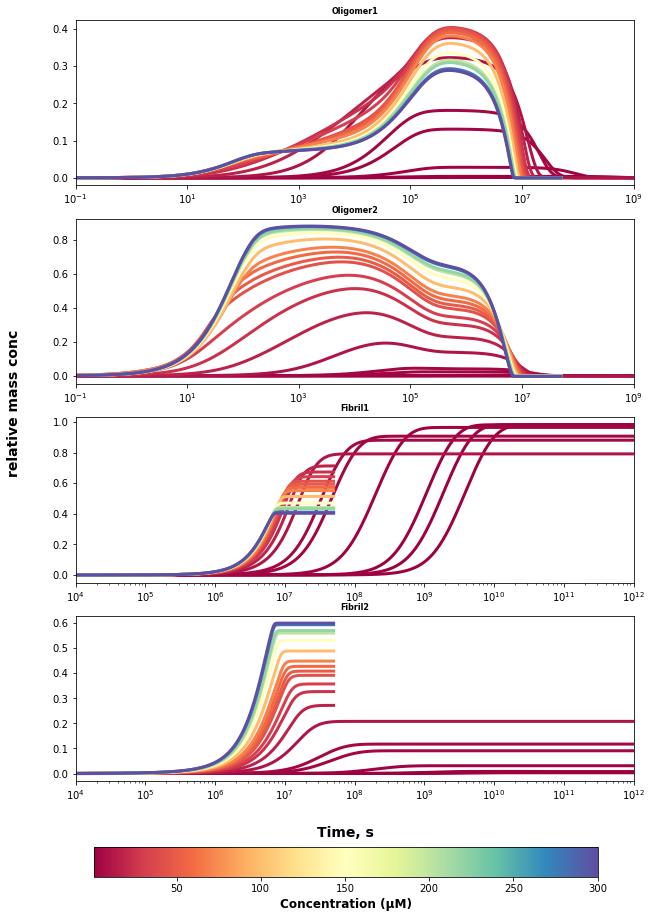

In [75]:
### Import package need to get the plot
from scipy.interpolate import interp1d
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
cmap = plt.get_cmap('tab20')
import matplotlib.pyplot as plt
import gc
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

#Define a function to plot time evolution of Oligomer1, oligomer2, Fibril1, Fibril2 in a column.
def plotSidebySide(x, conc, p, yscale='linear', selectedValues = None):
    fig, axs = plt.subplots(4, 1, figsize=(10, 14), sharex=False)
    fig.text(0.5, 0.07, 'Time, s', ha='center', fontsize=14, fontweight='bold')
    fig.text(0.03, 0.5, 'relative mass conc', va='center', rotation='vertical', fontsize=14, fontweight='bold')
    cmap = plt.get_cmap('Spectral')
    norm = mcolors.Normalize(vmin=min(conc), vmax=max(conc))
    titles = [
        'Oligomer1','Oligomer2','Fibril1','Fibril2']
    cindex =0
    for i in range(len(conc)):
        run =False
        if selectedValues ==None:
            run = True
        elif conc[i] in selectedValues:
            run = True
        if run:
            t = x[0 + 11 * i]
            if t[-1] >= 1e7:
                color = cmap(norm(conc[i]))
                o1 = (x[3 + 11 * i] + x[5 + 11 * i]) * p[4]
                o2 = (x[7 + 11 * i] + x[9 + 11 * i]) * p[24]
                f1 = x[4 + 11 * i] + x[6 + 11 * i]
                f2 = x[8 + 11 * i] + x[10 + 11 * i]
                threshold = -1
                signals = [o1, o2, f1, f2]
                masks = [s > threshold for s in signals]
                for j in range(4):
                    axs[j].plot(t[masks[j]], signals[j][masks[j]] / conc[i], color=color,
                            linewidth=3, label=f'{conc[i]}')

    # Set custom x-axis limits
    axs[0].set_xlim(1e-1, 1e9)
    axs[1].set_xlim(1e-1, 1e9)
    axs[2].set_xlim(1e4, 1e12)
    axs[3].set_xlim(1e4, 1e12)
    axs[0].set_xticklabels([])
    axs[2].set_xticklabels([])

    # Axis formatting
    for i in range(4):
        axs[i].set_yscale(yscale)
        axs[i].set_xscale('log')
        axs[i].set_title(titles[i], fontsize=8, fontweight='bold')

    # Add x-axis labels to the second and fourth subplots
    cbar_ax = fig.add_axes([0.15, 0.03, 0.7, 0.03])
    cbar_ax.set_xlim(min(conc), max(conc))
    cbar_ax.set_ylim(0, 1)
    cbar_ax.set_xticks(np.linspace(min(conc), max(conc), 5))
    cbar_ax.set_yticks([])
    cbar_ax.set_xlabel('Concentration (μM)', fontsize=12, fontweight='bold')
    cbar_ax.tick_params(axis='x', labelsize=10)

    # Draw colorbar using ScalarMappable
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # Needed for colorbar to work

    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Concentration (μM)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

    
### Define a function to load the three .npy files for concentration, time and fibril mass already computed above, and finally to plot and save the figure. 
def load_and_plot(dataset_names, save_prefixes=None, yscale='linear', save_format='eps', show=True):
    for i, name in enumerate(dataset_names):
        conc = np.load('conc_base_paperSU=10.npy')
        x = np.load('base_paperSU=10.npy')
        p = np.load('p_base_paperSU=10.npy')

        plotSidebySide(x, conc, p, yscale=yscale)

        if save_prefixes and save_prefixes[i]:
            plt.savefig(f'{save_prefixes[i]}.{save_format}')
        if show:
            plt.show()
        else:
            plt.close()

# Example usage:
dataset_names = ['paperSU=10']
save_prefixes = ['paperSU==10']
load_and_plot(dataset_names, save_prefixes)